In [1]:
import pandas as pd
import numpy as np
import datetime as dt

1. Load & inspect. Read both CSVs. Check shape, dtypes, nulls, and a few sample rows. Confirm date is parsed as a datetime, not a string.

In [4]:
transactions = pd.read_csv('data/transactions.csv')
products = pd.read_csv('data/products.csv')


In [5]:
transactions_rows, transactions_widght = transactions.shape
print(f"Transactions has {transactions_rows} rows and {transactions_widght} columns.")
print(f"Transactions has {transactions.isnull().sum().sum()} null values")
transactions.info()
print()

products_rows, products_width = products.shape
print(f"Products has {products_rows} rows and {products_width} columns.")
print(f"Products has {products.isnull().sum().sum()} null values")
products.info()

Transactions has 16740 rows and 6 columns.
Transactions has 0 null values
<class 'pandas.DataFrame'>
RangeIndex: 16740 entries, 0 to 16739
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  16740 non-null  str    
 1   date            16740 non-null  str    
 2   store_id        16740 non-null  str    
 3   product_id      16740 non-null  str    
 4   quantity        16740 non-null  int64  
 5   unit_price      16740 non-null  float64
dtypes: float64(1), int64(1), str(4)
memory usage: 784.8 KB

Products has 18 rows and 5 columns.
Products has 0 null values
<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    18 non-null     str    
 1   product_name  18 non-null     str    
 2   category      18 non-null     str    
 3   unit_price    18 non-null     floa

In [6]:
transactions['date'] = pd.to_datetime(transactions['date'])

transactions['date'].dtype # returns datetime dtype with microsecond precision

dtype('<M8[us]')

2. Revenue per transaction. Add a revenue column (quantity × unit_price). What's the total revenue across the dataset?

In [7]:
transactions['revenue'] = transactions['quantity'] * transactions['unit_price']

print(f"Total Revenue: {transactions.revenue.sum()}")

Total Revenue: 91108.75


3. Top sellers. Which 5 products generated the most revenue? Which 5 sold the most units? (They may not be the same.)

In [8]:
top_5_pids = pd.merge( \
    transactions.groupby('product_id'). \
        agg({'quantity':'sum', 'revenue':'sum'}),
    products, on="product_id")

top_5_products_by_revenue = top_5_pids. \
    sort_values('revenue', ascending=False). \
    head(5)['product_name']. \
    to_list()

top_5_products_by_units_sold = top_5_pids. \
    sort_values('quantity', ascending=False). \
    head(5)['product_name']. \
    to_list()
    

print(f"Top 5 Products by ...")
print(f"   Revenue:\t{top_5_products_by_revenue}")
print(f"   Units Sold:\t{top_5_products_by_units_sold}")

Top 5 Products by ...
   Revenue:	['Cold Brew', 'Latte', 'Mocha', 'Turkey Sandwich', 'Cappuccino']
   Units Sold:	['Cold Brew', 'Latte', 'Mocha', 'Cappuccino', 'Americano']


4. Category profit. Join the two tables. Compute profit per row (revenue − quantity × cost), then total profit per category. Which category is most profitable overall vs. most profitable per unit sold?

In [9]:
product_transactions = pd.merge(transactions, products, on='product_id')
product_transactions['profit'] = product_transactions['revenue'] - product_transactions['cost'] * product_transactions['quantity']


most_profitable_category = product_transactions.groupby('category')['profit'].sum().sort_values(ascending=False)
most_profita_per_units_sold = (
    product_transactions.groupby('category')['profit'].sum() 
    / product_transactions.groupby('category')['quantity'].sum()) \
    .sort_values(ascending=False).head(1)
most_profita_per_units_sold

print(f"Most Profitable Category: \t {most_profitable_category.idxmax()} (${most_profitable_category.max()})")
print(f"Category with Most Sold Units:\t {most_profita_per_units_sold.idxmax()} ({round(most_profita_per_units_sold.max(), 2)} $/unit)")

Most Profitable Category: 	 Coffee ($34162.55)
Category with Most Sold Units:	 Other (4.47 $/unit)


Most Profitable Day:	Series([], Name: revenue, dtype: float64)


Saturday    15447.55
Name: revenue, dtype: float64

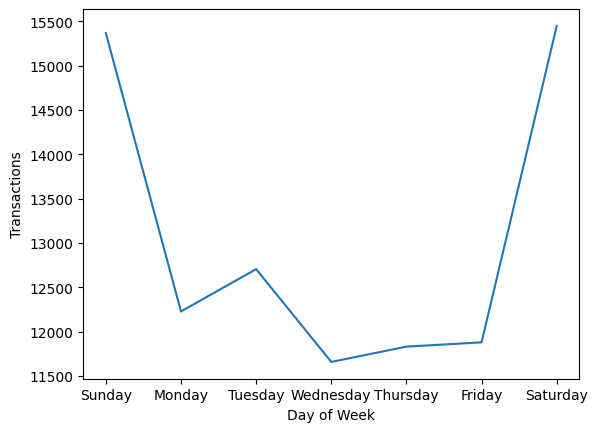

In [10]:
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday','Saturday']
daily_transactions = transactions.groupby(transactions['date'].dt.day_name())['revenue'].sum()

daily_transactions.index = pd.Categorical(daily_transactions.index, categories=day_order, ordered=True)
ax = daily_transactions.sort_index().plot()

ax.set_xlabel("Day of Week")
ax.set_ylabel("Transactions")

print(f'Most Profitable Day:\t{daily_transactions.sort_values(ascending=False).head(0)}')
display()
daily_transactions.sort_values(ascending=False).head(1)


5. Time patterns. Group by day of week and by hour-of-day (you'll need to add an hour column — assume the date includes a time, or invent one). When are the busiest sales hours?

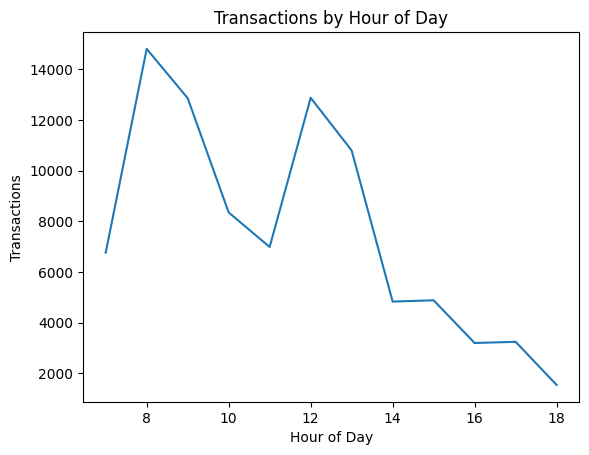

In [11]:
ax = transactions. \
    groupby(transactions['date'].dt.hour)['revenue']. \
    sum().sort_index(). \
    plot(title = "Transactions by Hour of Day")

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Transactions")

display()

 Does the answer change by category?

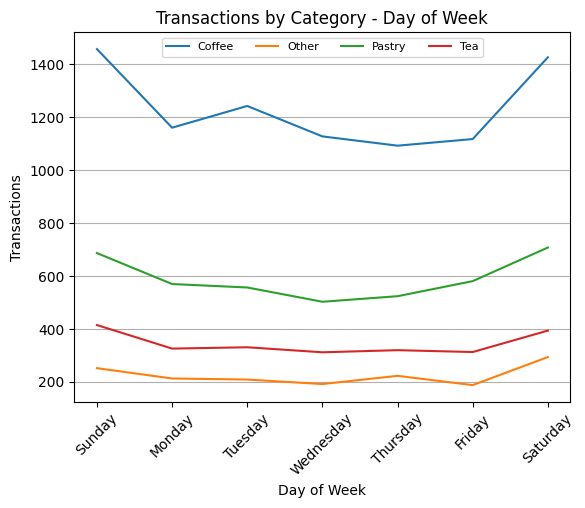

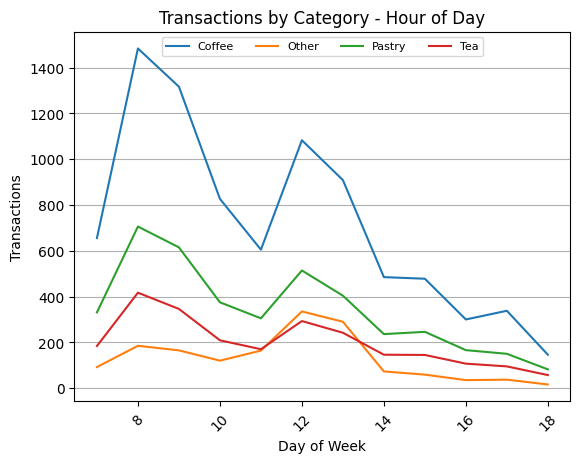

In [12]:
df = product_transactions.groupby([product_transactions['date'].dt.day_name(), 'category'])['transaction_id'].count()
df = df.unstack()

df.index = pd.Categorical(df.index, categories=day_order, ordered=True)

ax = df.sort_index().plot()
ax.set_xlabel('Day of Week')
ax.set_ylabel('Transactions')
ax.set_title('Transactions by Category - Day of Week')
ax.legend(loc='upper center', ncol=4, frameon=True,fontsize=8)
ax.tick_params(axis='x', labelrotation=45)
ax.grid(axis='y')

display()

# df = product_transactions.groupby([product_transactions['date'].dt.hour(), 'category'])['transaction_id'].count()

df = product_transactions. \
    groupby([product_transactions['date'].dt.hour, 'category'])['transaction_id']. \
    count().sort_index()
df = df.unstack()

ax = df.sort_index().plot()
ax.set_xlabel('Day of Week')
ax.set_ylabel('Transactions')
ax.set_title('Transactions by Category - Hour of Day')
ax.legend(loc='upper center', ncol=4, frameon=True,fontsize=8)
ax.tick_params(axis='x', labelrotation=45)
ax.grid(axis='y')

display()

6. Store comparison. For each store, compute monthly revenue. Reshape into a table where rows are months and columns are stores. Which store has the most consistent month-over-month growth?

In [13]:
df =  pd.merge(transactions, products, on='product_id')
df['month'] = df.date.dt.to_period('M')
monthly = df.pivot_table(index='month', columns='store_id', values='revenue', aggfunc='sum')
growth = monthly.pct_change() * 100
growth.std() / growth.mean()

store_id
S01     8.047681
S02    48.749208
S03     1.743875
dtype: float64

Store: S03 has the highest average growth of 6.49%


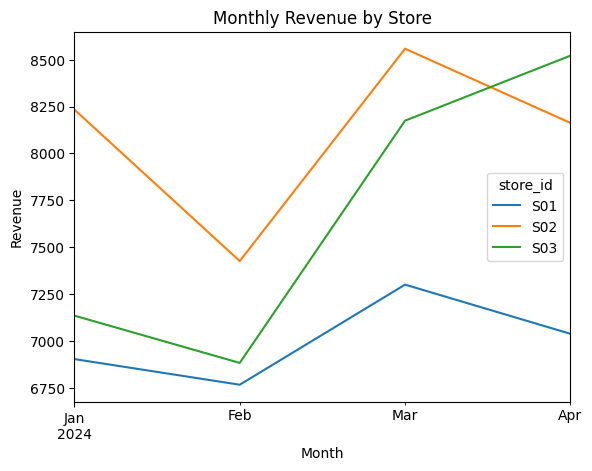

In [14]:
df =  pd.merge(transactions, products, on='product_id')
monthly_revenue_by_store = df.groupby([df.date.dt.to_period('M'), df.store_id]).revenue.sum().unstack()

(monthly_revenue_by_store['S01'] - monthly_revenue_by_store['S01'].shift(1)) * 100 / monthly_revenue_by_store['S01'].shift(1)



perc_diff_by_store = monthly_revenue_by_store.diff() * 100 / monthly_revenue_by_store.shift(1)

print(f"Store: {perc_diff_by_store.mean().idxmax()} has the highest average growth of {round(perc_diff_by_store.mean().max(), 2)}%")

ax = monthly_revenue_by_store.plot()
ax.set_title("Monthly Revenue by Store")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")

display()


7. (Stretch) Identify the "signature product" of each store — the product whose share of that store's revenue is the most disproportionately high compared to its share across the whole chain.

In [15]:
df = product_transactions = pd.merge(transactions, products, on='product_id')
df = df.groupby(['store_id', 'product_name'])['revenue'].sum().unstack().transpose()
df['Total'] = df.sum(axis=1)

df.apply(lambda x: x / x.Total, axis=1).idxmax()

store_id
S01             Latte
S02         Cold Brew
S03      Matcha Latte
Total    Almond Scone
dtype: str